# Atividade Prática — Aula 2: Pandas Essencial

Nesta atividade, você vai aplicar os conceitos da aula para explorar um dataset de vendas, fazer um **check-up inicial**, selecionar colunas relevantes, criar **filtros de negócio**, construir **rankings** e transformar resultados em **interpretação gerencial**.

**Dataset:** `vendas_dataviz_aula2.csv`

## Objetivos da atividade
- Ler e inspecionar um dataset com Pandas
- Entender a diferença entre DataFrame e Series
- Verificar tamanho, tipos e possíveis problemas de qualidade
- Selecionar apenas as colunas importantes para análise
- Filtrar dados com uma e múltiplas condições
- Criar rankings com `sort_values`, `nlargest` e `nsmallest`
- Interpretar resultados em linguagem de negócio


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para a atividade.
- `pandas`
- `numpy`
- `matplotlib.pyplot` (caso queira visualizar resultados)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Leitura do dataset

Leia o arquivo `vendas_dataviz_aula2.csv` em um DataFrame chamado `df`.
Depois, exiba as 5 primeiras linhas.


In [5]:
df = pd.read_csv('vendas_dataviz_aula2.csv')
df.head()

,data,produto,categoria,estado,canal,vendas,quantidade,preco_unitario,custo,lucro,avaliacao_cliente
0,2024-04-12,Mouse Gamer,Periféricos,RJ,Marketplace,562.26,3,187.42,97.70,269.16,4.6
1,2024-05-01,Headset,Áudio,ES,MarketPlace,1124.08,4,281.02,144.77,545.00,3.8
2,2024-10-03,Teclado Mecânico,Periféricos,SP,Marketplace,2515.73,7,359.39,153.66,1440.11,4.3
3,2024-07-06,Webcam HD,Periféricos,SP,Marketplace,596.76,3,198.92,125.09,221.49,4.3
4,2024-02-24,Smartwatch,Telefonia,RJ,Loja Física,3908.08,4,977.02,666.26,1243.04,4.4


## 3. Anatomia dos dados: DataFrame e Series

### Questão 1
Explique, com base no que foi visto em aula:
1. O que é um **DataFrame**?
2. O que é uma **Series**?
3. Mostre no código uma coluna isolada do DataFrame.


1.Um DataFrame é uma estrutura de dados bidimensional do Pandas, semelhante a uma tabela. Ele possui linhas e colunas, onde cada coluna pode ter um tipo de dado diferente.
2.Uma Series é uma estrutura unidimensional do Pandas, ou seja, representa uma única coluna do DataFrame. Ela possui um índice e valores, funcionando como uma lista rotulada.

In [8]:
# Carregar o dataset
df = pd.read_csv('vendas_dataviz_aula2.csv')

# Selecionar uma coluna
serie_produto = df['produto']

# Verificar tipo e visualizar
print(type(serie_produto))
print(serie_produto.head())

<class 'pandas.core.series.Series'>
0         Mouse Gamer
1             Headset
2    Teclado Mecânico
3           Webcam HD
4          Smartwatch
Name: produto, dtype: object


## 4. Check-up inicial do dataset

Um analista profissional sempre começa verificando o tamanho, a estrutura e a qualidade inicial dos dados.

### Questão 2
Use:
- `df.shape`
- `df.info()`
- `df.dtypes`

Depois responda:
1. Quantas linhas e colunas existem?
2. Quais colunas parecem numéricas?
3. Há sinais de valores ausentes?
4. Existe alguma coluna com tipo inadequado?


In [9]:
# Carregar dataset
df = pd.read_csv('vendas_dataviz_aula2.csv')

# Estrutura
print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nTipos de dados:")
print(df.dtypes)

Shape:
(450, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data               450 non-null    object 
 1   produto            450 non-null    object 
 2   categoria          450 non-null    object 
 3   estado             449 non-null    object 
 4   canal              450 non-null    object 
 5   vendas             450 non-null    object 
 6   quantidade         450 non-null    int64  
 7   preco_unitario     450 non-null    float64
 8   custo              450 non-null    float64
 9   lucro              450 non-null    float64
 10  avaliacao_cliente  448 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 38.8+ KB

Tipos de dados:
data                  object
produto               object
categoria             object
estado                object
canal                 object
vendas                

## 5. Inspeção de problemas de qualidade

Na aula, vimos que dashboards podem falhar por causa de dados mal preparados.

### Questão 3
Investigue:
- valores nulos
- categorias inconsistentes
- números armazenados como texto
- valores infinitos

Dica:
- `df.isna().sum()`
- `df['canal'].value_counts(dropna=False)`
- `df['estado'].value_counts(dropna=False)`
- `np.isinf(...)`


In [10]:
# Carregar dataset
df = pd.read_csv('vendas_dataviz_aula2.csv')

# =========================
# 1. Valores nulos
# =========================
print("Valores nulos por coluna:")
print(df.isna().sum())

# =========================
# 2. Categorias inconsistentes
# =========================
print("\nCategorias em canal:")
print(df['canal'].value_counts(dropna=False))

print("\nCategorias em estado:")
print(df['estado'].value_counts(dropna=False))

# =========================
# 3. Tipos de dados (números como texto)
# =========================
print("\nTipos de dados:")
print(df.dtypes)

# =========================
# 4. Valores infinitos
# =========================
print("\nValores infinitos no dataset:")
print(np.isinf(df.select_dtypes(include=[float, int])).sum())

Valores nulos por coluna:
data                 0
produto              0
categoria            0
estado               1
canal                0
vendas               0
quantidade           0
preco_unitario       0
custo                0
lucro                0
avaliacao_cliente    2
dtype: int64

Categorias em canal:
canal
Marketplace    152
Online         148
Loja Física    147
MarketPlace      1
online           1
ONLINE           1
Name: count, dtype: int64

Categorias em estado:
estado
ES     62
SP     52
BA     52
GO     49
PE     48
SC     42
MG     39
RS     38
RJ     36
PR     30
rj      1
NaN     1
Name: count, dtype: int64

Tipos de dados:
data                  object
produto               object
categoria             object
estado                object
canal                 object
vendas                object
quantidade             int64
preco_unitario       float64
custo                float64
lucro                float64
avaliacao_cliente    float64
dtype: object

Valores infin

In [11]:
# Verifique se há valores infinitos na coluna lucro
pd.Series(np.isinf(pd.to_numeric(df['lucro'], errors='coerce'))).value_counts(dropna=False)

,count
lucro,
False,448
True,2


## 6. Selecionando o que importa

Nem toda análise precisa de todas as colunas. Vamos criar um recorte mais focado para responder perguntas de negócio.

### Questão 4
Crie um novo DataFrame chamado `df_dash` contendo apenas as colunas:
- `data`
- `estado`
- `canal`
- `produto`
- `categoria`
- `vendas`
- `lucro`

Use `.copy()` para evitar problemas futuros.


In [12]:
cols_dashboard = ['data', 'estado', 'canal', 'produto', 'categoria', 'vendas', 'lucro']
df_dash = df[cols_dashboard].copy()

df_dash.head()

,data,estado,canal,produto,categoria,vendas,lucro
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04


## 7. Preparação mínima para análise

Algumas colunas podem precisar de ajuste antes de ordenar e agregar.

### Questão 5
1. Converta a coluna `data` para formato de data.
2. Crie uma coluna `mes` a partir da data.
3. Tente converter `vendas` para numérico, tratando possíveis textos.
4. Crie uma coluna chamada `vendas_num`.


In [13]:
df_dash['data'] = pd.to_datetime(df_dash['data'], errors='coerce')
df_dash['mes'] = df_dash['data'].dt.to_period('M')

# Limpeza simples para a coluna vendas (remove símbolo R$, espaços e troca vírgula decimal)
vendas_limpa = (
    df_dash['vendas']
    .astype(str)
    .str.replace('R\$', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df_dash['vendas_num'] = pd.to_numeric(vendas_limpa, errors='coerce')
df_dash.head()

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2007/1170284534.py:8: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('R\$', '', regex=True)


,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16,2024-04,56226.0
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00,2024-05,112408.0
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11,2024-10,251573.0
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49,2024-07,59676.0
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04,2024-02,390808.0


## 8. Filtragem simples: recorte de negócio

Na aula, vimos o exemplo de filtrar apenas o estado do Rio de Janeiro.

### Questão 6
Crie um DataFrame `df_rj` contendo apenas registros do estado `RJ`.
Depois responda:
1. Quantos registros existem nesse recorte?
2. Qual a soma de vendas no RJ?


In [14]:
df_rj = df_dash[df_dash['estado'] == 'RJ']
df_rj.shape, df_rj['vendas_num'].sum()

((36, 9), np.float64(13161085.0))

## 9. Filtragem com múltiplas condições

Agora faça um recorte mais profissional: apenas vendas do estado do RJ no canal Online.

### Questão 7
Faça esse filtro de duas formas:
1. Usando operadores lógicos com `&`
2. Usando `query()`


In [15]:
df_rj_online = df_dash[(df_dash['estado'] == 'RJ') & (df_dash['canal'] == 'Online')]
df_rj_online.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0


In [16]:
df_rj_online_q = df_dash.query("estado == 'RJ' and canal == 'Online'")
df_rj_online_q.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0


## 10. Priorização: rankings

Gestores raramente leem tabelas enormes. Eles querem os **Top N**.

### Questão 8
Gere:
1. Os 10 registros com maior valor de `vendas_num`
2. Os 10 registros com maior `lucro`
3. Os 5 registros com menor `lucro`

Observe se aparece algum valor suspeito.


In [17]:
top10_vendas = df_dash.sort_values('vendas_num', ascending=False).head(10)
top10_vendas

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0
387,2024-12-26,ES,Online,Tablet Plus,Telefonia,19061.82,5200.11,2024-12,1906182.0
74,2024-10-01,PR,Loja Física,Notebook Pro,Informática,18782.88,5744.80,2024-10,1878288.0
245,2024-12-26,SP,Marketplace,Smartphone X,Telefonia,18417.28,3773.84,2024-12,1841728.0
216,2024-07-22,SC,Online,Notebook Pro,Informática,17715.88,5747.00,2024-07,1771588.0
368,2024-05-29,SP,Online,Smartphone X,Telefonia,17631.48,5392.08,2024-05,1763148.0


In [18]:
# Primeiro garantimos que lucro esteja numérico
df_dash['lucro_num'] = pd.to_numeric(df_dash['lucro'], errors='coerce')

top10_lucro = df_dash.nlargest(10, 'lucro_num')
top10_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
199,2024-02-06,ES,Online,Caixa de Som,Áudio,792.12,inf,2024-02,79212.0,inf
449,2024-06-10,SP,Marketplace,Teclado Mecânico,Periféricos,1818.06,inf,2024-06,181806.0,inf
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0,13556.90
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0,10319.12
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0,9411.00
442,2024-02-21,PR,Loja Física,Notebook Pro,Informática,19782.0,8546.28,2024-02,197820.0,8546.28
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0,8103.88
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0,6869.60
110,2024-06-28,BA,Loja Física,Smartphone X,Telefonia,16138.55,6519.65,2024-06,1613855.0,6519.65
109,2024-09-20,PE,Marketplace,Tablet Plus,Telefonia,14602.02,6151.92,2024-09,1460202.0,6151.92


In [19]:
bottom5_lucro = df_dash.nsmallest(5, 'lucro_num')
bottom5_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
415,2024-10-11,MG,Loja Física,Mouse Gamer,Periféricos,158.6,60.58,2024-10,1586.0,60.58
273,2024-09-15,ES,Online,Mouse Gamer,Periféricos,160.85,65.92,2024-09,16085.0,65.92
48,2024-10-31,GO,Online,Mouse Gamer,Periféricos,175.18,71.29,2024-10,17518.0,71.29
42,2024-09-12,RJ,Loja Física,Mouse Gamer,Periféricos,176.14,74.89,2024-09,17614.0,74.89
143,2024-05-20,SC,Marketplace,Webcam HD,Periféricos,203.3,77.72,2024-05,2033.0,77.72


## 11. Ranking por produto

Agora vamos sair do nível do registro e pensar em **resultado por produto**.

### Questão 9
Agrupe por produto e calcule:
- soma de vendas
- soma de lucro

Depois:
1. Mostre os 10 produtos mais lucrativos
2. Interprete o resultado em linguagem de negócio


In [20]:
ranking_produtos = (
    df_dash.groupby('produto', dropna=False)
    .agg(
        vendas_total=('vendas_num', 'sum'),
        lucro_total=('lucro_num', 'sum')
    )
    .sort_values('lucro_total', ascending=False)
)

ranking_produtos.head(10)

,vendas_total,lucro_total
produto,,
Caixa de Som,7215206.00,inf
Teclado Mecânico,5060975.80,inf
Notebook Pro,37921671.00,135237.36
Smartphone X,33625813.00,94603.87
Tablet Plus,28875008.00,90646.58
Smartwatch,14919206.00,68124.96
Monitor 27,14780460.00,67019.52
Headset,4640667.00,24471.32
Mouse Gamer,2419618.00,15472.38


## 12. Ranking por estado e canal

### Questão 10
Crie dois rankings:
1. Estados com maior receita total
2. Canais com maior lucro total

Depois escreva uma interpretação curta para cada ranking.


In [21]:
ranking_estados = (
    df_dash.groupby('estado', dropna=False)['vendas_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_dash.groupby('canal', dropna=False)['lucro_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_estados, ranking_canais

(estado
 SP     23403073.80
 BA     20158371.00
 PE     18892544.00
 ES     18574418.00
 GO     14113942.00
 PR     13521454.00
 RJ     13161085.00
 SC     11724060.00
 MG      9848069.17
 RS      8334753.60
 rj       124332.00
 NaN       92685.00
 Name: vendas_num, dtype: float64,
 canal
 Online               inf
 Marketplace          inf
 Loja Física    185020.38
 ONLINE           1206.02
 MarketPlace       545.00
 online            433.53
 Name: lucro_num, dtype: float64)

## 13. Análise temporal simples

### Questão 11
Agrupe os dados por `mes` e calcule a receita total mensal.
Depois responda:
1. Há meses de maior desempenho?
2. Existe indício de sazonalidade?


In [22]:
receita_mensal = (
    df_dash.groupby('mes')['vendas_num']
    .sum()
    .sort_index()
)

receita_mensal

,vendas_num
mes,
2024-01,8382201.17
2024-02,11408379.00
2024-03,11955532.00
2024-04,13191093.00
2024-05,17767992.80
2024-06,15375535.00
2024-07,5973168.00
2024-08,13881684.60
2024-09,14733533.00


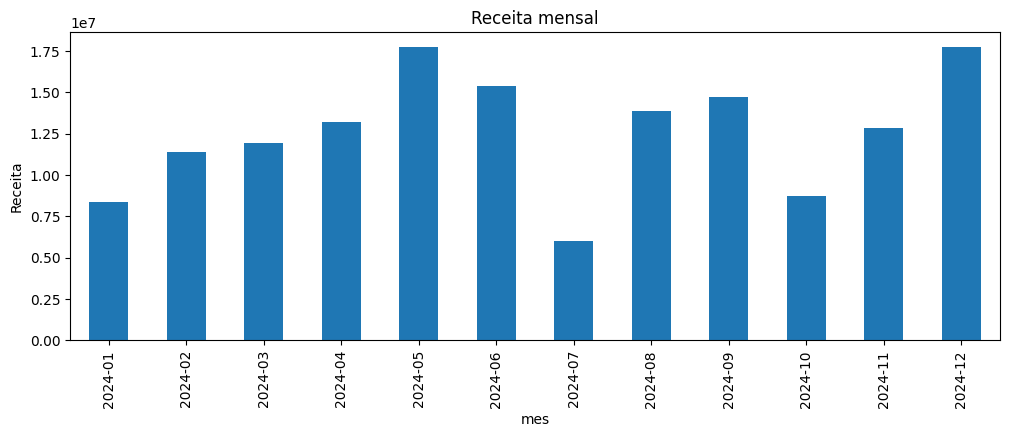

In [23]:
receita_mensal.plot(kind='bar', figsize=(12,4), title='Receita mensal')
plt.ylabel('Receita')
plt.show()

## 14. A última milha: interpretação

Na aula, vimos que um analista não entrega apenas tabela — entrega **decisão**.

### Questão 12
Com base nos resultados do notebook, escreva interpretações gerenciais para:
1. O produto mais lucrativo
2. O estado com maior receita
3. O canal com maior lucro
4. Um possível problema de qualidade encontrado


## 15. Desafio extra (opcional)

Faça uma limpeza adicional do dataset:
- padronize valores de `canal` (`online`, `ONLINE`, `MarketPlace`, etc.)
- padronize `estado` (`rj` -> `RJ`)
- substitua infinitos em `lucro_num` por `NaN`
- trate valores ausentes como julgar adequado

Depois gere novamente os rankings e compare os resultados.


In [24]:
print("=== ANTES ===")

ranking_canal_antes = df_dash.groupby('canal')['vendas_num'].sum().sort_values(ascending=False)
ranking_estado_antes = df_dash.groupby('estado')['vendas_num'].sum().sort_values(ascending=False)

print("\nRanking por canal (antes):")
print(ranking_canal_antes)

print("\nRanking por estado (antes):")
print(ranking_estado_antes)


# =========================
# LIMPEZA
# =========================

# 1. Padronizar canal
df_dash['canal'] = (
    df_dash['canal']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'online': 'Online',
        'e-commerce': 'Online',
        'ecommerce': 'Online',
        'marketplace': 'Marketplace',
        'market place': 'Marketplace',
        'loja fisica': 'Loja Física',
        'loja física': 'Loja Física'
    })
)

# 2. Padronizar estado
df_dash['estado'] = df_dash['estado'].astype(str).str.upper().str.strip()

# 3. Substituir infinitos em lucro_num (se existir)
if 'lucro_num' in df_dash.columns:
    df_dash['lucro_num'] = df_dash['lucro_num'].replace([np.inf, -np.inf], np.nan)

# 4. Tratar valores ausentes
df_dash['canal'] = df_dash['canal'].fillna('Desconhecido')
df_dash['estado'] = df_dash['estado'].fillna('Desconhecido')
df_dash['vendas_num'] = df_dash['vendas_num'].fillna(0)

# =========================
# DEPOIS
# =========================
print("\n=== DEPOIS ===")

ranking_canal_depois = df_dash.groupby('canal')['vendas_num'].sum().sort_values(ascending=False)
ranking_estado_depois = df_dash.groupby('estado')['vendas_num'].sum().sort_values(ascending=False)

print("\nRanking por canal (depois):")
print(ranking_canal_depois)

print("\nRanking por estado (depois):")
print(ranking_estado_depois)

=== ANTES ===

Ranking por canal (antes):
canal
Online         58107339.17
Loja Física    46842459.60
Marketplace    46358659.80
ONLINE           427868.00
MarketPlace      112408.00
online           100053.00
Name: vendas_num, dtype: float64

Ranking por estado (antes):
estado
SP    23403073.80
BA    20158371.00
PE    18892544.00
ES    18574418.00
GO    14113942.00
PR    13521454.00
RJ    13161085.00
SC    11724060.00
MG     9848069.17
RS     8334753.60
rj      124332.00
Name: vendas_num, dtype: float64

=== DEPOIS ===

Ranking por canal (depois):
canal
Online         58635260.17
Loja Física    46842459.60
Marketplace    46471067.80
Name: vendas_num, dtype: float64

Ranking por estado (depois):
estado
SP     23403073.80
BA     20158371.00
PE     18892544.00
ES     18574418.00
GO     14113942.00
PR     13521454.00
RJ     13285417.00
SC     11724060.00
MG      9848069.17
RS      8334753.60
NAN       92685.00
Name: vendas_num, dtype: float64


## 16. Entrega esperada

Seu notebook deve demonstrar:
- organização
- comentários explicativos
- código legível
- interpretação de negócio

### Fechamento
Ao terminar, salve o notebook com suas respostas e envie junto com o arquivo CSV utilizado.
